# Análisis de PAT (Pulse Arrival Time) — ECG + PPG
PAT = t(dPPG/dt máx) − t(pico R del ECG), latido a latido.
- ECG: Pan-Tompkins (pasabanda → derivada → cuadrado → integración de ventana móvil).
- PPG: selector V5 entre pleth_1..pleth_6 por SQI espectral + coincidencia con FC del ECG.
- Todos los filtros con `filtfilt` (fase cero): sin retardo de grupo, clave para medir tiempos.

Primero se definen las funciones; después: 1° análisis temporal, 2° frecuencial, 3° tabla resumen de todas las señales.

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, welch, periodogram
from scipy.interpolate import CubicSpline
from scipy.stats import skew

ARCHIVOS = sorted(glob.glob("data/signal_*.csv"))  # local
try:  # En Colab: subir uno o varios CSV
    from google.colab import files
    ARCHIVOS = sorted(files.upload())
except ImportError:
    pass
FS = 500.0  # Hz (muestras cada 2 ms)
print(ARCHIVOS)


def pasabanda(x, f1, f2, orden=3):
    b, a = butter(orden, [f1, f2], btype="band", fs=FS)
    return filtfilt(b, a, x)  # fase cero

['data/signal_1_1.csv', 'data/signal_1_2.csv', 'data/signal_1_3.csv', 'data/signal_3_1.csv', 'data/signal_3_2.csv', 'data/signal_3_3.csv']


## ECG — Pan-Tompkins

In [2]:
def pan_tompkins(ecg):
    ecg_f = pasabanda(ecg - np.median(ecg), 5, 15)
    if skew(ecg_f) < 0:  # QRS invertido: dejar R positivo
        ecg_f = -ecg_f
    der = np.gradient(ecg_f) * FS
    cuad = der ** 2
    win = int(0.150 * FS)  # 150 ms
    mwi = np.convolve(cuad, np.ones(win) / win, mode="same")

    # Umbral adaptativo sobre la integración (SPKI/NPKI clásico, simplificado)
    cand, _ = find_peaks(mwi, distance=int(0.25 * FS))  # refractario 250 ms
    spki, npki = np.percentile(mwi[cand], 90), np.percentile(mwi[cand], 30)
    qrs = []
    for c in cand:
        umbral = npki + 0.25 * (spki - npki)
        if mwi[c] > umbral:
            spki = 0.125 * mwi[c] + 0.875 * spki
            qrs.append(c)
        else:
            npki = 0.125 * mwi[c] + 0.875 * npki
    # Refinar: pico R = máximo del ECG filtrado en ±100 ms alrededor del QRS integrado
    r = []
    w = int(0.100 * FS)
    for q in qrs:
        i0, i1 = max(q - w, 0), min(q + w, len(ecg_f))
        r.append(i0 + np.argmax(ecg_f[i0:i1]))
    return np.unique(r), ecg_f

## PPG — Selector inteligente V5 (SQI espectral + coincidencia cardíaca)
- Pasabanda 0.5–8 Hz: corta el artefacto de movimiento/respiración (<0.5 Hz).
- SQI = potencia en ±0.2 Hz de la FC (y 2° armónico) / potencia total 0.5–8 Hz.
- Coincidencia: pico espectral dominante del PPG vs FC del ECG.
- Polaridad: la subida sistólica es rápida → se elige el signo con derivada de asimetría positiva.

In [3]:
def sqi_ppg(x, fc_hz):
    f, p = welch(x, fs=FS, nperseg=int(16 * FS))
    banda = (f >= 0.5) & (f <= 8)
    cerca = lambda f0: np.abs(f - f0) <= 0.2
    sqi = p[cerca(fc_hz) | cerca(2 * fc_hz)].sum() / p[banda].sum()
    f_dom = f[banda][np.argmax(p[banda])]
    coincide = np.exp(-abs(f_dom - fc_hz) / 0.15)  # 1 si coincide con la FC
    return sqi, f_dom, sqi * coincide


def seleccionar_ppg(df, fc_hz):
    ppg_f, tabla = {}, []
    for c in [f"pleth_{i}" for i in range(1, 7)]:
        x = pasabanda(df[c].to_numpy(float), 0.5, 8)
        if skew(np.gradient(x)) < 0:
            x = -x
        ppg_f[c] = x
        sqi, f_dom, score = sqi_ppg(x, fc_hz)
        tabla.append((c, sqi, f_dom * 60, score))
    tabla = pd.DataFrame(tabla, columns=["canal", "SQI", "FC_ppg_lpm", "score"]).sort_values("score", ascending=False)
    mejor = tabla.iloc[0]["canal"]
    return mejor, ppg_f[mejor], tabla

## PAT latido a latido
Máximo de dPPG/dt entre R+80 ms y el R siguiente (máx. 800 ms), con interpolación parabólica
(resolución < 2 ms). Latidos fuera de mediana ± 3·MAD se descartan.

In [4]:
def calcular_pat(r_idx, dppg):
    pat_t, pat, rr = [], [], []
    for i, r in enumerate(r_idx[:-1]):
        i0 = r + int(0.08 * FS)
        i1 = min(r_idx[i + 1], r + int(0.8 * FS))
        if i1 <= i0:
            continue
        k = i0 + np.argmax(dppg[i0:i1])
        y0, y1, y2 = dppg[k - 1], dppg[k], dppg[k + 1]
        dk = 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2) if (y0 - 2 * y1 + y2) != 0 else 0.0
        pat_t.append(r / FS)
        pat.append((k + dk - r) / FS * 1000)  # ms
        rr.append((r_idx[i + 1] - r) / FS * 1000)  # ms
    pat_t, pat, rr = map(np.array, (pat_t, pat, rr))
    med = np.median(pat)
    mad = 1.4826 * np.median(np.abs(pat - med))
    ok = np.abs(pat - med) <= 3 * mad
    return pat_t, pat, rr, ok

## PSD del PAT [ms²/Hz]
- Serie latido a latido (no uniforme) → spline cúbica a 4 Hz.
- Se resta la media (sin detrend lineal, para no borrar ULF/VLF).
- Periodograma Hann sobre todo el registro: resolución 1/T ≈ 0,002 Hz (Welch con segmentos cortos borraría ULF/VLF).
- Potencia por banda = integral de la PSD (trapecios) → ms².

⚠️ Con ~500 s la ULF (< 0,003 Hz, períodos > 5,5 min) cae en 1–2 bins: valor orientativo
(la ULF se define para registros de 24 h).

In [5]:
FS_I = 4.0  # Hz, remuestreo uniforme
BANDAS = {"ULF": (0.0, 0.003, "#8e44ad"), "VLF": (0.003, 0.04, "#2980b9"),
          "LF": (0.04, 0.15, "#27ae60"), "HF": (0.15, 0.4, "#e67e22")}


def psd_pat(pat_t, pat):
    ti = np.arange(pat_t[0], pat_t[-1], 1 / FS_I)
    pat_i = CubicSpline(pat_t, pat)(ti)
    pat_i -= pat_i.mean()
    f, psd = periodogram(pat_i, fs=FS_I, window="hann", nfft=2**16, scaling="density")  # ms²/Hz
    pot = {}
    for b, (f1, f2, _) in BANDAS.items():
        m = (f >= f1) & (f <= f2)
        pot[b] = np.trapezoid(psd[m], f[m])
    return ti, pat_i, f, psd, pot

## Pipeline completo por archivo

In [6]:
def analizar(archivo):
    df = pd.read_csv(archivo)
    r_idx, ecg_f = pan_tompkins(df["ecg"].to_numpy(float))
    fc_hz = 1 / np.median(np.diff(r_idx) / FS)
    mejor, ppg, tabla_ppg = seleccionar_ppg(df, fc_hz)
    dppg = np.gradient(ppg) * FS
    pat_t, pat, rr, ok = calcular_pat(r_idx, dppg)
    ti, pat_i, f, psd, pot = psd_pat(pat_t[ok], pat[ok])

    # Validación Pan-Tompkins contra la columna 'peaks' del dataset (tolerancia 50 ms)
    sens = np.nan
    if "peaks" in df:
        ref = np.flatnonzero(df["peaks"].to_numpy())
        sens = 100 * np.mean([np.min(np.abs(r_idx - p)) <= 0.05 * FS for p in ref])

    pv = pat[ok]
    consec = ok[1:] & ok[:-1]  # diferencias sólo entre latidos válidos consecutivos
    total = sum(pot.values())
    hf = (f >= 0.15) & (f <= 0.4)
    fila = {
        "señal": archivo.split("/")[-1].replace(".csv", ""),
        "duración (s)": len(df) / FS,
        "canal PPG": mejor,
        "SQI PPG": tabla_ppg.iloc[0]["SQI"],
        "sens. R (%)": sens,
        "latidos": len(pat),
        "válidos (%)": 100 * ok.mean(),
        "FC (lpm)": 60000 / rr[ok].mean(),
        "PAT medio (ms)": pv.mean(),
        "PAT DE (ms)": pv.std(ddof=1),
        "PAT CV (%)": 100 * pv.std(ddof=1) / pv.mean(),
        "PAT RMSSD (ms)": np.sqrt(np.mean(np.diff(pat)[consec] ** 2)),
        "PAT mín (ms)": pv.min(),
        "PAT máx (ms)": pv.max(),
        "r(PAT,RR)": np.corrcoef(pv, rr[ok])[0, 1],
        **{f"{b} (ms²)": p for b, p in pot.items()},
        "Total (ms²)": total,
        **{f"{b} (%)": 100 * p / total for b, p in pot.items()},
        "ULF/VLF": pot["ULF"] / pot["VLF"],
        "LF/HF": pot["LF"] / pot["HF"],
        "LFnu": 100 * pot["LF"] / (pot["LF"] + pot["HF"]),
        "HFnu": 100 * pot["HF"] / (pot["LF"] + pot["HF"]),
        "pico HF (Hz)": f[hf][np.argmax(psd[hf])],
    }
    fila["FR estimada (rpm)"] = 60 * fila["pico HF (Hz)"]
    return dict(fila=fila, df=df, r_idx=r_idx, ecg_f=ecg_f, mejor=mejor, ppg=ppg, dppg=dppg,
                tabla_ppg=tabla_ppg, pat_t=pat_t, pat=pat, ok=ok, ti=ti, pat_i=pat_i, f=f, psd=psd, pot=pot)

# 1° Análisis Temporal — PAT vs tiempo
Detalle de la primera señal (cambiar `ARCHIVO` para ver otra).

  canal   SQI  FC_ppg_lpm  score
pleth_6 0.937      71.250  0.835
pleth_5 0.933      71.250  0.831
pleth_4 0.865      71.250  0.771
pleth_3 0.849      71.250  0.757
pleth_1 0.844      71.250  0.752
pleth_2 0.840      71.250  0.749
Canal seleccionado: pleth_6  |  picos R: 613  |  sensibilidad vs referencia: 100.0 %
PAT: 599/612 latidos válidos | media 287.0 ms | DE 7.0 ms | rango 266–305 ms


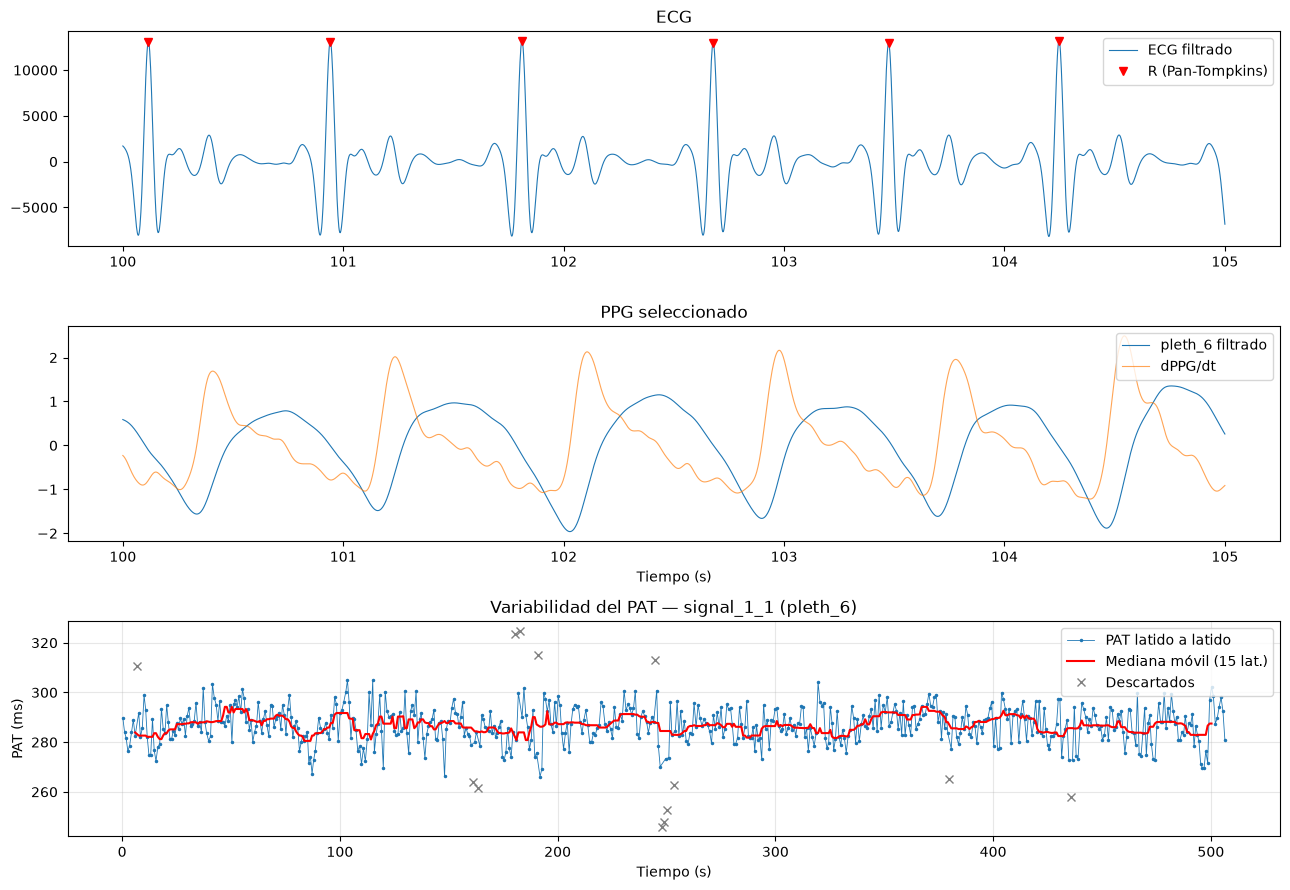

In [7]:
ARCHIVO = ARCHIVOS[0]
R = analizar(ARCHIVO)
nombre = R["fila"]["señal"]
t = np.arange(len(R["df"])) / FS
print(R["tabla_ppg"].to_string(index=False, float_format="%.3f"))
print(f"Canal seleccionado: {R['mejor']}  |  picos R: {len(R['r_idx'])}  |  "
      f"sensibilidad vs referencia: {R['fila']['sens. R (%)']:.1f} %")
ok, pat, pat_t = R["ok"], R["pat"], R["pat_t"]
print(f"PAT: {ok.sum()}/{len(pat)} latidos válidos | media {pat[ok].mean():.1f} ms "
      f"| DE {pat[ok].std():.1f} ms | rango {pat[ok].min():.0f}–{pat[ok].max():.0f} ms")

fig, ax = plt.subplots(3, 1, figsize=(13, 9))
v = (t >= 100) & (t <= 105)  # ventana de 5 s de muestra
ecg_f, r_idx, ppg, dppg = R["ecg_f"], R["r_idx"], R["ppg"], R["dppg"]
ax[0].plot(t[v], ecg_f[v], lw=0.8, label="ECG filtrado")
rv = r_idx[(t[r_idx] >= 100) & (t[r_idx] <= 105)]
ax[0].plot(t[rv], ecg_f[rv], "rv", label="R (Pan-Tompkins)")
ax[0].legend(loc="upper right"); ax[0].set_title("ECG")
ax[1].plot(t[v], ppg[v] / np.std(ppg), lw=0.8, label=f"{R['mejor']} filtrado")
ax[1].plot(t[v], dppg[v] / np.std(dppg), lw=0.8, alpha=0.7, label="dPPG/dt")
ax[1].legend(loc="upper right"); ax[1].set_title("PPG seleccionado")
ax[1].set_xlabel("Tiempo (s)")

ax[2].plot(pat_t[ok], pat[ok], ".-", lw=0.6, ms=3, label="PAT latido a latido")
ax[2].plot(pat_t[ok], pd.Series(pat[ok]).rolling(15, center=True).median(), "r", lw=1.5, label="Mediana móvil (15 lat.)")
ax[2].plot(pat_t[~ok], pat[~ok], "x", color="gray", label="Descartados")
ax[2].set_xlabel("Tiempo (s)"); ax[2].set_ylabel("PAT (ms)")
ax[2].set_title(f"Variabilidad del PAT — {nombre} ({R['mejor']})")
ax[2].legend(loc="upper right"); ax[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"pat_{nombre}.png", dpi=120)
plt.show()

# 2° Análisis Frecuencial — PSD por bandas
(a) PSD global del registro vs frecuencia.

Banda Rango (Hz)  Potencia (ms²)  % del total
  ULF  0.0–0.003           0.178        0.439
  VLF 0.003–0.04           7.006       17.316
   LF  0.04–0.15          15.605       38.570
   HF   0.15–0.4          17.670       43.675
Total 0–0.4 Hz: 40.46 ms²  |  LF/HF = 0.88


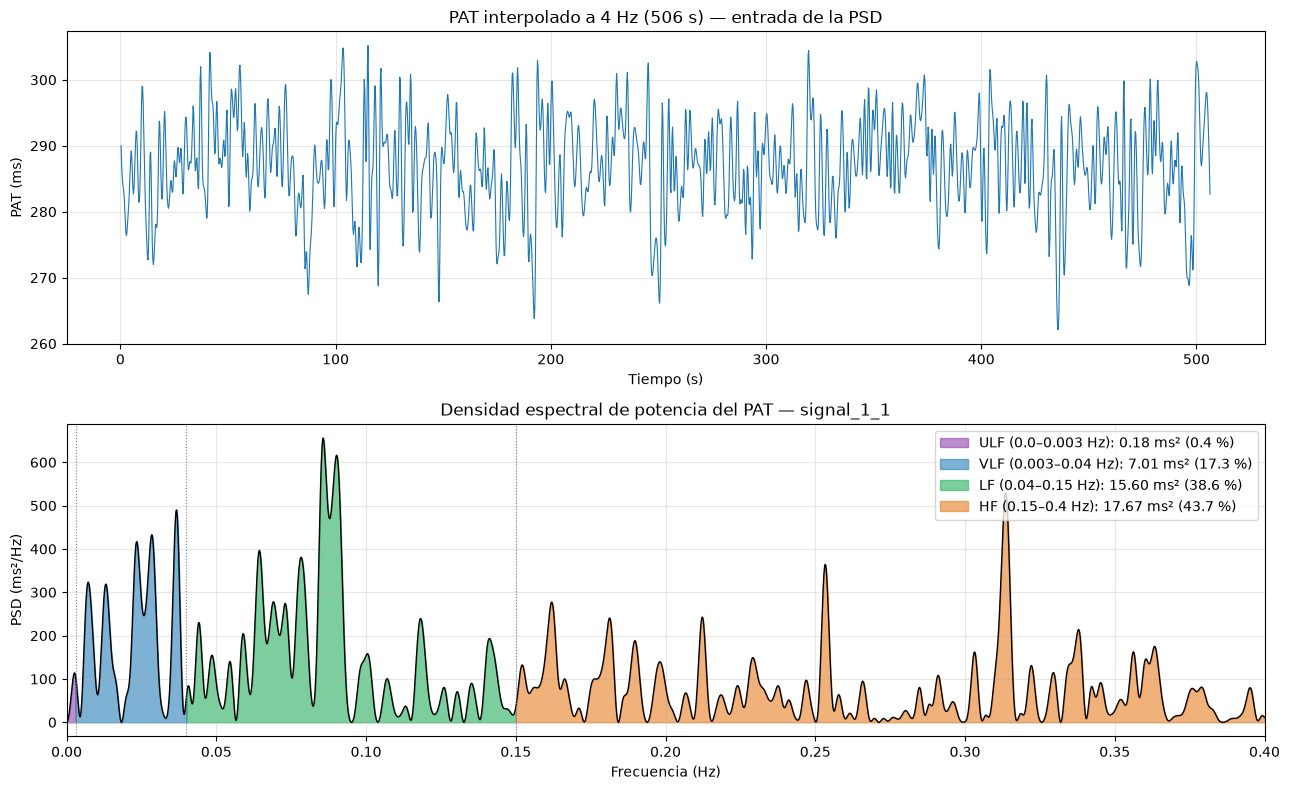

In [8]:
f, psd, pot, ti, pat_i = R["f"], R["psd"], R["pot"], R["ti"], R["pat_i"]
total = sum(pot.values())
print(pd.DataFrame({"Banda": list(pot), "Rango (Hz)": [f"{v[0]}–{v[1]}" for v in BANDAS.values()],
                    "Potencia (ms²)": list(pot.values()),
                    "% del total": [100 * p / total for p in pot.values()]}).to_string(index=False, float_format="%.3f"))
print(f"Total 0–0.4 Hz: {total:.2f} ms²  |  LF/HF = {pot['LF'] / pot['HF']:.2f}")

fig, ax = plt.subplots(2, 1, figsize=(13, 8))
ax[0].plot(ti, pat_i + pat[ok].mean(), lw=0.8)
ax[0].set_xlabel("Tiempo (s)"); ax[0].set_ylabel("PAT (ms)")
ax[0].set_title(f"PAT interpolado a {FS_I:g} Hz ({ti[-1] - ti[0]:.0f} s) — entrada de la PSD"); ax[0].grid(alpha=0.3)

m04 = f <= 0.4
ax[1].plot(f[m04], psd[m04], "k", lw=1)
for b, (f1, f2, col) in BANDAS.items():
    m = (f >= f1) & (f <= f2)
    ax[1].fill_between(f[m], psd[m], color=col, alpha=0.6,
                       label=f"{b} ({f1}–{f2} Hz): {pot[b]:.2f} ms² ({100 * pot[b] / total:.1f} %)")
    ax[1].axvline(f2, color="gray", ls=":", lw=0.8)
ax[1].set_xlim(0, 0.4)
ax[1].set_xlabel("Frecuencia (Hz)"); ax[1].set_ylabel("PSD (ms²/Hz)")
ax[1].set_title(f"Densidad espectral de potencia del PAT — {nombre}")
ax[1].legend(loc="upper right"); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"psd_{nombre}.png", dpi=120)
plt.show()

## 2° (b) PSD por bandas vs tiempo (500 s)
La PSD es una función de la frecuencia; para verla a lo largo de los ~500 s se usa un espectrograma (STFT, ventana Hann de 120 s, paso 10 s, fase cero no aplica: sólo se estima potencia).
- Arriba: PSD [ms²/Hz] en color, tiempo en X, frecuencia en Y con los límites de banda.
- Abajo: PSD media de cada banda [ms²/Hz] vs tiempo, con color bajo la curva.

⚠️ Con ventanas de 120 s la resolución es ≈ 0,008 Hz: la ULF (< 0,003 Hz) no se puede resolver en el tiempo y la VLF sólo parcialmente. Por eso ULF queda fuera de este gráfico (está en la PSD global).

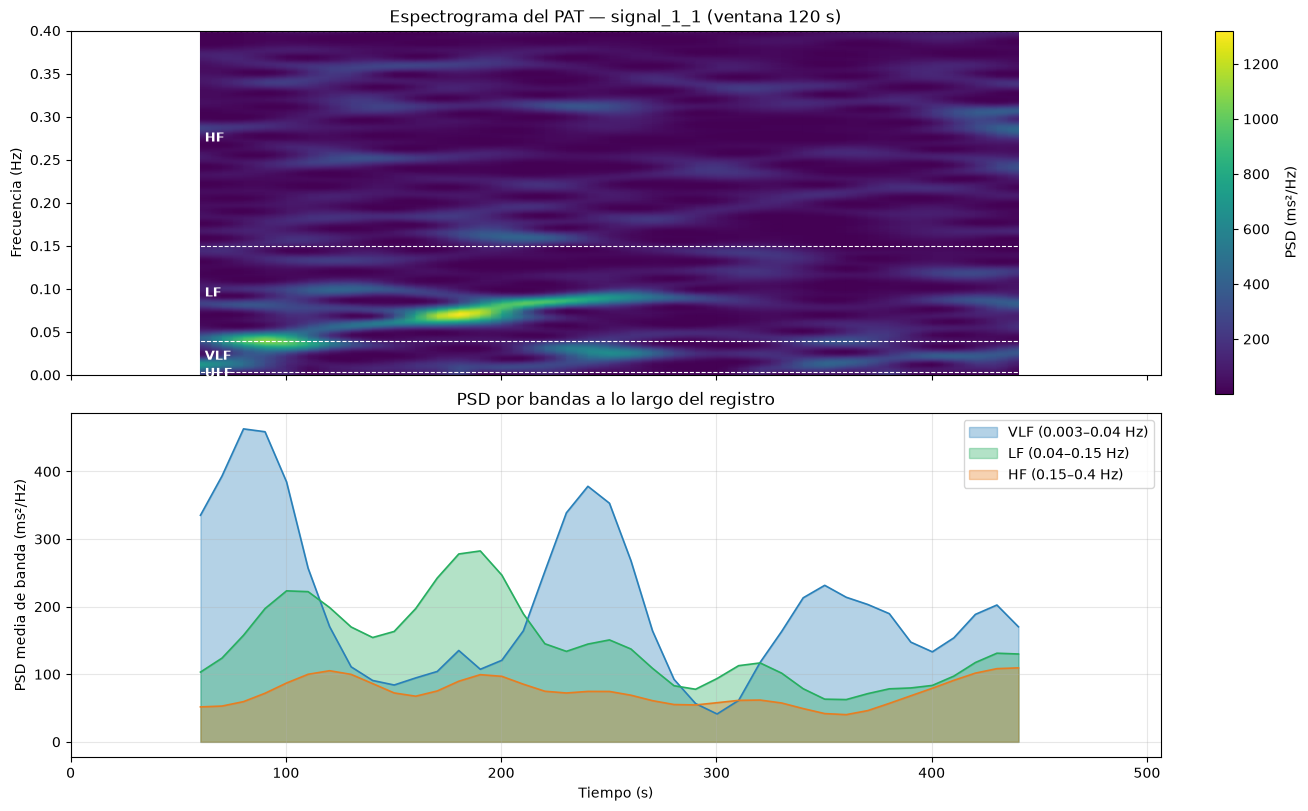

In [9]:
from scipy.signal import spectrogram

VENT = 120  # s
fs_, ts_, Sxx = spectrogram(pat_i, fs=FS_I, window="hann", nperseg=int(VENT * FS_I),
                            noverlap=int((VENT - 10) * FS_I), nfft=2**12, scaling="density")
ts_ = ts_ + ti[0]

fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True, layout="constrained")
m04 = fs_ <= 0.4
im = ax[0].pcolormesh(ts_, fs_[m04], Sxx[m04], shading="gouraud", cmap="viridis")
fig.colorbar(im, ax=ax, label="PSD (ms²/Hz)", shrink=0.5, anchor=(0, 1))
for b, (f1, f2, col) in BANDAS.items():
    ax[0].axhline(f2, color="w", ls="--", lw=0.8)
    ax[0].text(ts_[0] + 2, (f1 + f2) / 2, b, color="w", va="center", fontsize=9, fontweight="bold")
ax[0].set_ylabel("Frecuencia (Hz)"); ax[0].set_ylim(0, 0.4)
ax[0].set_title(f"Espectrograma del PAT — {nombre} (ventana {VENT} s)")

for b, (f1, f2, col) in list(BANDAS.items())[1:]:  # ULF no resoluble con 120 s
    m = (fs_ >= f1) & (fs_ <= f2)
    dens = Sxx[m].mean(axis=0)
    ax[1].plot(ts_, dens, color=col, lw=1.2)
    ax[1].fill_between(ts_, dens, color=col, alpha=0.35, label=f"{b} ({f1}–{f2} Hz)")
ax[1].set_xlabel("Tiempo (s)"); ax[1].set_ylabel("PSD media de banda (ms²/Hz)")
ax[1].set_title("PSD por bandas a lo largo del registro")
ax[1].legend(loc="upper right"); ax[1].grid(alpha=0.3)
ax[1].set_xlim(0, ti[-1])
plt.savefig(f"psd_tiempo_{nombre}.png", dpi=120)
plt.show()

# 3° Tabla resumen — todas las señales
Además de lo pedido (PAT medio, potencia por banda, %, ULF/VLF, LF/HF) se agregan, por ser comparables entre señales:
- **Calidad:** canal PPG elegido, SQI, sensibilidad de Pan-Tompkins vs `peaks`, % de latidos válidos.
- **Dominio temporal:** DE, CV (dispersión relativa, independiente del PAT medio), RMSSD (variabilidad latido a latido), mín/máx.
- **FC** y **r(PAT,RR)**: acople entre tiempo de tránsito y ciclo cardíaco.
- **LFnu / HFnu:** unidades normalizadas, comparables aunque cambie la potencia total.
- **Pico HF → FR estimada:** la modulación respiratoria del PAT.

In [10]:
resumen = pd.DataFrame([analizar(a)["fila"] for a in ARCHIVOS]).set_index("señal")
resumen.to_csv("resumen_pat.csv", float_format="%.4f")
pd.set_option("display.float_format", "{:.3f}".format)
tabla = resumen.T
tabla["media"] = resumen.select_dtypes("number").mean()
tabla["DE"] = resumen.select_dtypes("number").std()
tabla

señal,signal_1_1,signal_1_2,signal_1_3,signal_3_1,signal_3_2,signal_3_3,media,DE
duración (s),508.052,491.804,490.548,492.298,493.174,487.454,493.888,7.219
canal PPG,pleth_6,pleth_3,pleth_2,pleth_3,pleth_3,pleth_6,NaN,NaN
SQI PPG,0.937,0.816,0.835,0.809,0.784,0.822,0.834,0.053
sens. R (%),100.000,97.784,99.848,100.000,100.000,97.238,99.145,1.279
latidos,612,836,672,602,703,739,694.000,87.111
válidos (%),97.876,89.833,96.875,100.000,99.004,86.604,95.032,5.478
FC (lpm),72.379,97.860,81.561,73.549,85.658,85.579,82.764,9.364
PAT medio (ms),287.009,239.557,219.296,292.770,269.577,276.500,264.118,28.776
PAT DE (ms),7.054,9.888,7.127,7.930,5.699,7.746,7.574,1.378
PAT CV (%),2.458,4.128,3.250,2.709,2.114,2.801,2.910,0.706


# 4° Tabla — 6 señales
Parámetros en filas, señales en columnas, más media y DE entre señales. Se exporta a `resumen_pat.xlsx` (con formato, lista para el informe).

In [11]:
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

GRUPOS = {  # parámetro -> sección de la tabla
    "Calidad de señal": ["duración (s)", "canal PPG", "SQI PPG", "sens. R (%)", "latidos", "válidos (%)"],
    "Dominio temporal": ["FC (lpm)", "PAT medio (ms)", "PAT DE (ms)", "PAT CV (%)", "PAT RMSSD (ms)",
                         "PAT mín (ms)", "PAT máx (ms)", "r(PAT,RR)"],
    "PSD por bandas (ms²)": [f"{b} (ms²)" for b in BANDAS] + ["Total (ms²)"],
    "Contribución (%)": [f"{b} (%)" for b in BANDAS],
    "Ratios / normalizadas": ["ULF/VLF", "LF/HF", "LFnu", "HFnu", "pico HF (Hz)", "FR estimada (rpm)"],
}
filas = [(g, p) for g, ps in GRUPOS.items() for p in ps]
final = tabla.loc[[p for _, p in filas]]
final.index = pd.MultiIndex.from_tuples(filas, names=["Sección", "Parámetro"])
display(final)

ruta = "resumen_pat.xlsx"
with pd.ExcelWriter(ruta, engine="openpyxl") as xw:
    final.to_excel(xw, sheet_name="Resumen")
    ws = xw.sheets["Resumen"]
    borde = Border(*(Side(style="thin", color="999999"),) * 4)
    for fila in ws.iter_rows(min_row=1, max_row=ws.max_row, max_col=ws.max_column):
        for c in fila:
            c.border = borde
            if isinstance(c.value, float):
                c.number_format = "0.000" if abs(c.value) < 10 else "0.0"
            c.alignment = Alignment(horizontal="center", vertical="center")
    for c in ws[1]:
        c.font = Font(bold=True, color="FFFFFF")
        c.fill = PatternFill("solid", fgColor="2C3E50")
    for c in ws["A"][1:]:
        c.font = Font(bold=True)
    ws.column_dimensions["A"].width = 24
    ws.column_dimensions["B"].width = 20
    for col in "CDEFGHIJ":
        ws.column_dimensions[col].width = 13
    ws.freeze_panes = "C2"
print(f"Guardado: {ruta}")

señal                                   signal_1_1 signal_1_2 signal_1_3  \
Sección               Parámetro                                            
Calidad de señal      duración (s)         508.052    491.804    490.548   
                      canal PPG            pleth_6    pleth_3    pleth_2   
                      SQI PPG                0.937      0.816      0.835   
                      sens. R (%)          100.000     97.784     99.848   
                      latidos                  612        836        672   
                      válidos (%)           97.876     89.833     96.875   
Dominio temporal      FC (lpm)              72.379     97.860     81.561   
                      PAT medio (ms)       287.009    239.557    219.296   
                      PAT DE (ms)            7.054      9.888      7.127   
                      PAT CV (%)             2.458      4.128      3.250   
                      PAT RMSSD (ms)         8.299     13.682      7.057   
                      PAT mín (ms)         266.154    210.216    199.639   
                      PAT máx (ms)         304.939    267.165    240.728   
                      r(PAT,RR)              0.019     -0.002      0.049   
PSD por bandas (ms²)  ULF (ms²)              0.178      0.930     17.100   
                      VLF (ms²)              7.006      8.370     10.923   
                      LF (ms²)              15.605     10.997      5.915   
                      HF (ms²)              17.670     21.034      9.780   
                      Total (ms²)           40.458     41.331     43.719   
Contribución (%)      ULF (%)                0.439      2.250     39.114   
                      VLF (%)               17.316     20.252     24.986   
                      LF (%)                38.570     26.608     13.529   
                      HF (%)                43.675     50.891     22.371   
Ratios / normalizadas ULF/VLF                0.025      0.111      1.565   
                      LF/HF                  0.883      0.523      0.605   
                      LFnu                  46.896     34.333     37.685   
                      HFnu                  53.104     65.667     62.315   
                      pico HF (Hz)           0.314      0.293      0.172   
                      FR estimada (rpm)     18.812     17.593     10.316   

señal                                   signal_3_1 signal_3_2 signal_3_3  \
Sección               Parámetro                                            
Calidad de señal      duración (s)         492.298    493.174    487.454   
                      canal PPG            pleth_3    pleth_3    pleth_6   
                      SQI PPG                0.809      0.784      0.822   
                      sens. R (%)          100.000    100.000     97.238   
                      latidos                  602        703        739   
                      válidos (%)          100.000     99.004     86.604   
Dominio temporal      FC (lpm)              73.549     85.658     85.579   
                      PAT medio (ms)       292.770    269.577    276.500   
                      PAT DE (ms)            7.930      5.699      7.746   
                      PAT CV (%)             2.709      2.114      2.801   
                      PAT RMSSD (ms)         7.970      5.083      8.816   
                      PAT mín (ms)         272.999    254.482    250.733   
                      PAT máx (ms)         313.690    285.279    300.281   
                      r(PAT,RR)             -0.207     -0.221     -0.024   
PSD por bandas (ms²)  ULF (ms²)              2.498      0.932      2.154   
                      VLF (ms²)             11.629      7.498      5.169   
                      LF (ms²)              10.363      5.886     14.319   
                      HF (ms²)              33.072     13.861     22.189   
                      Total (ms²)           57.562     28.177     43.831   
Contribución (%)      ULF (%)                4.

Guardado: resumen_pat.xlsx


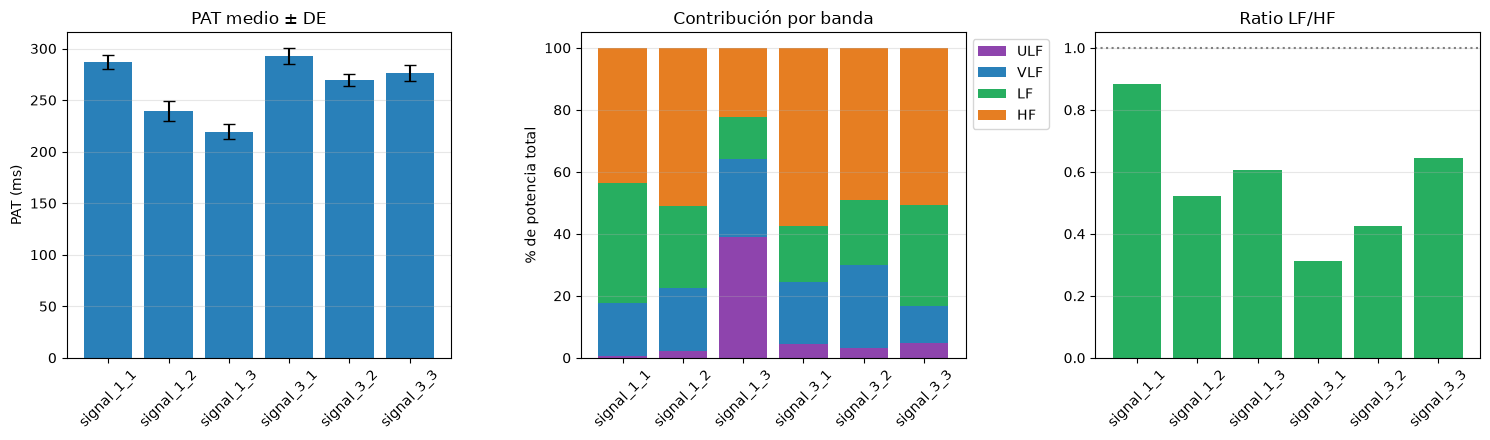

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
x = resumen.index
ax[0].bar(x, resumen["PAT medio (ms)"], yerr=resumen["PAT DE (ms)"], capsize=4, color="#2980b9")
ax[0].set_ylabel("PAT (ms)"); ax[0].set_title("PAT medio ± DE")
fondo = np.zeros(len(x))
for b, (_, _, col) in BANDAS.items():
    ax[1].bar(x, resumen[f"{b} (%)"], bottom=fondo, color=col, label=b)
    fondo += resumen[f"{b} (%)"].to_numpy()
ax[1].set_ylabel("% de potencia total"); ax[1].set_title("Contribución por banda"); ax[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
ax[2].bar(x, resumen["LF/HF"], color="#27ae60")
ax[2].axhline(1, color="gray", ls=":")
ax[2].set_title("Ratio LF/HF")
for a in ax:
    a.tick_params(axis="x", rotation=45); a.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("resumen_pat.png", dpi=120)
plt.show()